# 📊 Customer Churn Prediction Using Machine Learning

## 📌 Project Overview

This project predicts whether a bank customer is likely to churn using Machine Learning.

The project covers data cleaning, exploratory data analysis, feature engineering, data preprocessing, model training, model evaluation, and customer churn prediction.

## 🎯 Objectives

- Understand customer churn patterns
- Perform data cleaning and exploratory data analysis
- Prepare data for Machine Learning
- Build classification models
- Evaluate model performance
- Predict customer churn
- Identify important factors affecting customer churn

## 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 12)


In [3]:
# Display the first 5 rows of the dataset
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Display dataset information
# This shows column names, data types, and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


In [5]:
# Display descriptive statistics for numerical columns
# This helps us understand the distribution and range of the numerical features
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Display unique values in categorical columns
# This helps us understand the categories present in the dataset

print("Unique countries:")
print(df["country"].unique())

print("\nUnique genders:")
print(df["gender"].unique())

Unique countries:
<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

Unique genders:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [7]:
# Check for duplicate rows in the dataset
# Duplicate records can affect the quality of our Machine Learning model

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# Check for missing values in each column
# Missing values need to be handled before training the Machine Learning model

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


**Churn distribution :**

In [9]:
# Count the number of customers in each churn category
# 0 = Customer stayed
# 1 = Customer churned

churn_counts = df["churn"].value_counts().sort_index()

print("Churn distribution:")
print(churn_counts)

Churn distribution:
churn
0    7963
1    2037
Name: count, dtype: int64


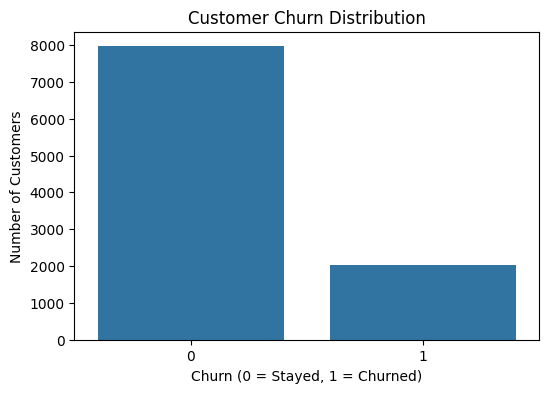

In [10]:
# Create a count plot to visualize customer churn distribution
# This helps us compare customers who stayed with customers who churned

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="churn")

# Add chart title and axis labels
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

**Gender distribution :**

In [11]:
# Count customers by gender
# This helps us understand the gender distribution in the dataset

gender_counts = df["gender"].value_counts()

print("Gender distribution:")
print(gender_counts)

Gender distribution:
gender
Male      5457
Female    4543
Name: count, dtype: int64


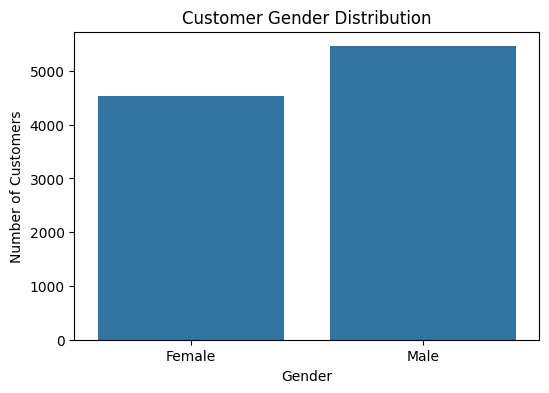

In [12]:
# Create a count plot to visualize gender distribution
# This helps us compare the number of male and female customers

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="gender")

# Add chart title and axis labels
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

**Country distribution :**

In [13]:
# Count customers by country
# This helps us understand how customers are distributed geographically

country_counts = df["country"].value_counts()

print("Country distribution:")
print(country_counts)

Country distribution:
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


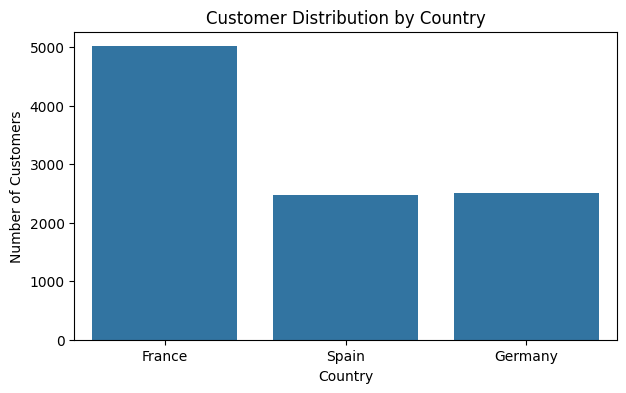

In [14]:
# Create a count plot to visualize country distribution
# This helps us compare the number of customers across countries

plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="country")

# Add chart title and axis labels
plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

**Age Distribution :**

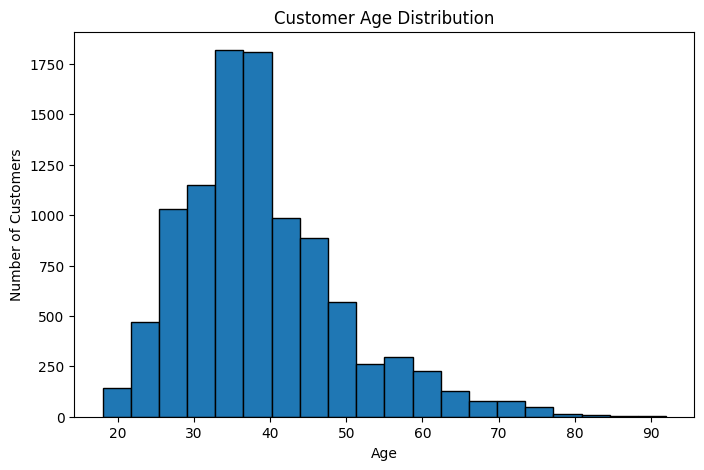

In [15]:
# Plot the distribution of customer ages
# This helps us understand the age range of customers in the dataset

plt.figure(figsize=(8, 5))

# Create a histogram of customer ages
plt.hist(df["age"], bins=20, edgecolor="black")

# Add chart title and axis labels
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Display the chart
plt.show()

In [16]:
# Calculate the number of churned and non-churned customers by gender
gender_churn = pd.crosstab(df["gender"], df["churn"])

# Display the churn distribution by gender
print("Churn distribution by gender:")
print(gender_churn)

Churn distribution by gender:
churn      0     1
gender            
Female  3404  1139
Male    4559   898


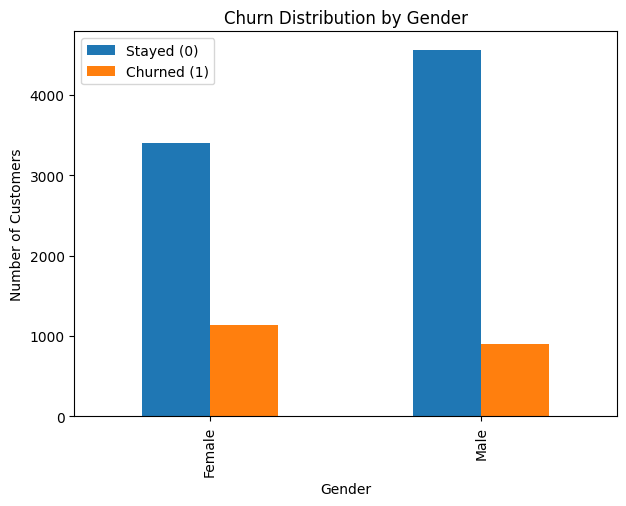

In [17]:
# Plot churn distribution by gender
gender_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

In [18]:
# Calculate churn distribution by country
country_churn = pd.crosstab(df["country"], df["churn"])

# Display churn distribution by country
print("Churn distribution by country:")
print(country_churn)

Churn distribution by country:
churn       0    1
country           
France   4204  810
Germany  1695  814
Spain    2064  413


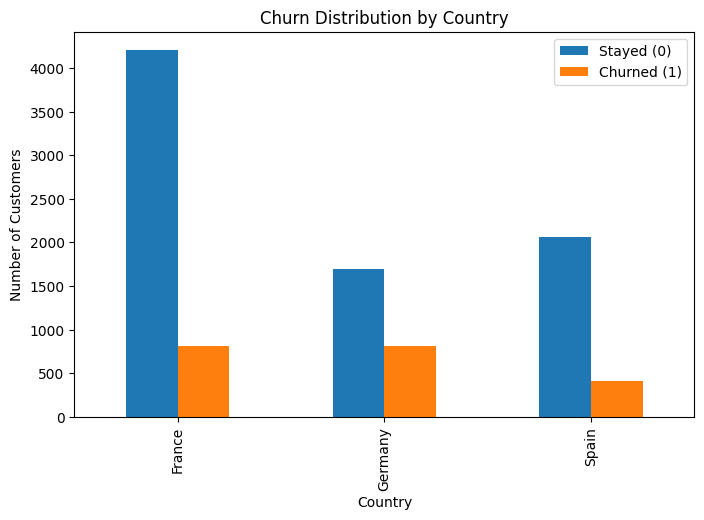

In [19]:
# Plot churn distribution by country
country_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

In [20]:
# Create age groups for customer segmentation
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 65, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

# Calculate churn distribution by age group
age_churn = pd.crosstab(df["age_group"], df["churn"])

# Display churn distribution by age group
print("Churn distribution by age group:")
print(age_churn)

Churn distribution by age group:
churn         0    1
age_group           
18-25       565   46
26-35      3241  301
36-45      3003  733
46-55       648  663
56-65       277  259
66+         229   35


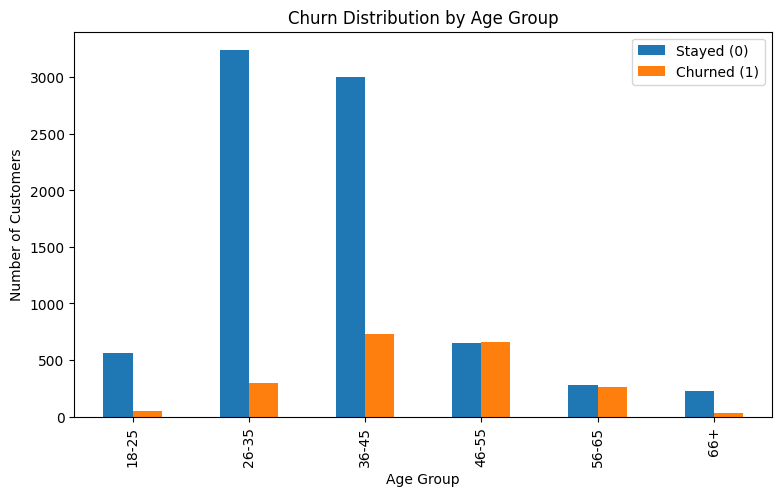

In [21]:
# Plot churn distribution by age group
age_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

In [22]:
# Create credit score groups for analysis
df["credit_score_group"] = pd.cut(
    df["credit_score"],
    bins=[300, 500, 600, 700, 800, 900],
    labels=["300-500", "501-600", "601-700", "701-800", "801-900"]
)

# Calculate churn distribution by credit score group
credit_score_churn = pd.crosstab(
    df["credit_score_group"],
    df["churn"]
)

# Display churn distribution by credit score group
print("Churn distribution by credit score group:")
print(credit_score_churn)

Churn distribution by credit score group:
churn                  0    1
credit_score_group           
300-500              491  152
501-600             1910  513
601-700             3065  753
701-800             1979  492
801-900              518  127


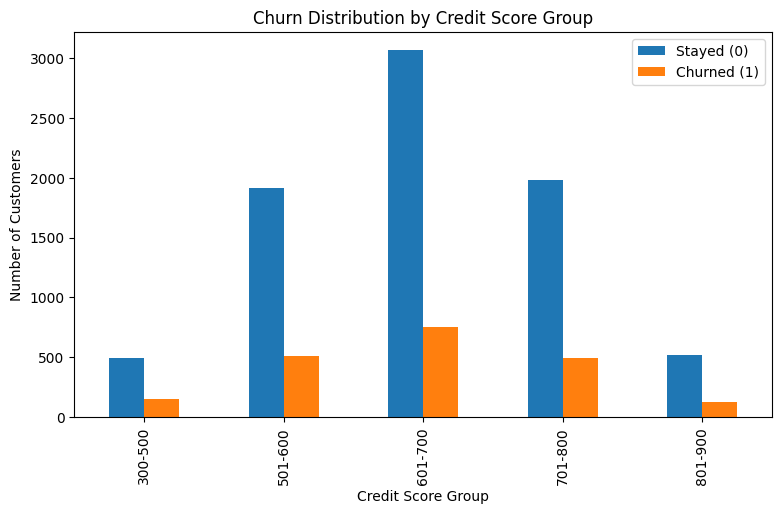

In [23]:
# Plot churn distribution by credit score group
credit_score_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

In [24]:
# Calculate churn distribution by customer tenure
tenure_churn = pd.crosstab(
    df["tenure"],
    df["churn"]
)

# Display churn distribution by tenure
print("Churn distribution by tenure:")
print(tenure_churn)

Churn distribution by tenure:
churn     0    1
tenure          
0       318   95
1       803  232
2       847  201
3       796  213
4       786  203
5       803  209
6       771  196
7       851  177
8       828  197
9       771  213
10      389  101


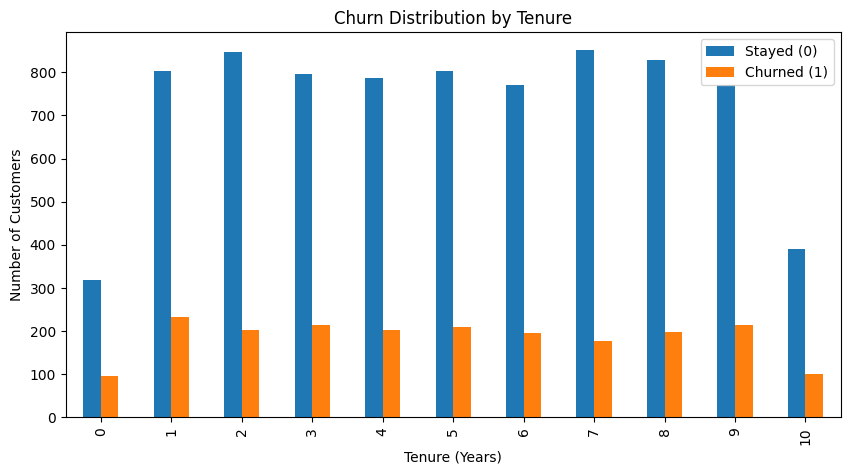

In [25]:
# Plot churn distribution by customer tenure
tenure_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

In [26]:
# Calculate churn distribution by number of products
products_churn = pd.crosstab(
    df["products_number"],
    df["churn"]
)

# Display churn distribution by number of products
print("Churn distribution by number of products:")
print(products_churn)

Churn distribution by number of products:
churn               0     1
products_number            
1                3675  1409
2                4242   348
3                  46   220
4                   0    60


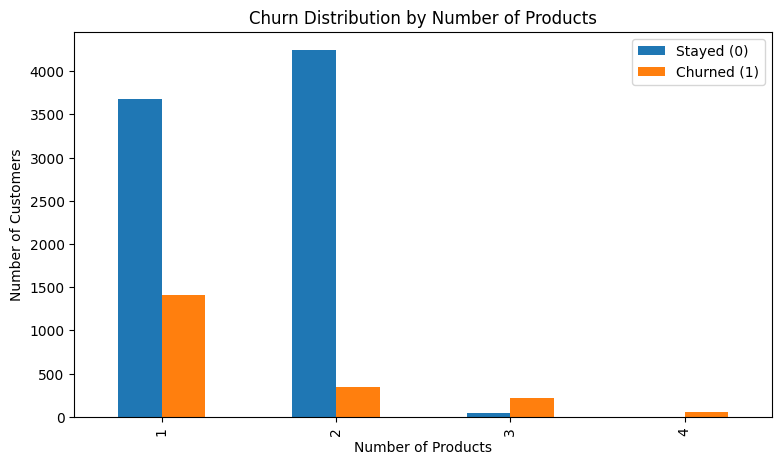

In [27]:
# Plot churn distribution by number of products
products_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

Average balance by churn status:
churn
0    72745.296779
1    91108.539337
Name: balance, dtype: float64


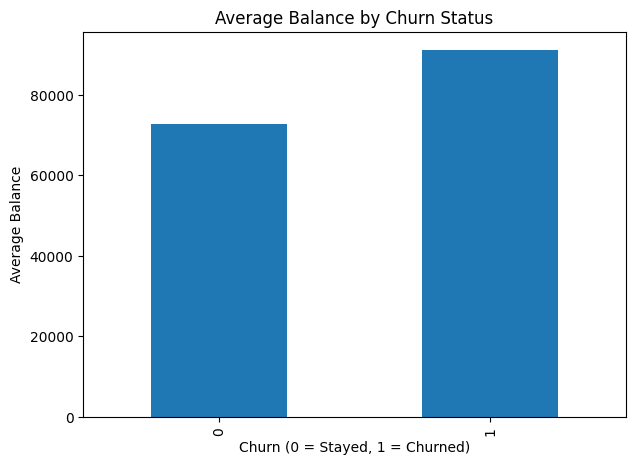

In [28]:
# Compare customer balance with churn status
# This helps us understand whether account balance is related to customer churn

balance_churn = df.groupby("churn")["balance"].mean()

# Display the average balance for each churn category
print("Average balance by churn status:")
print(balance_churn)

# Plot the average balance for churned and non-churned customers
balance_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

# Add chart title and axis labels
plt.title("Average Balance by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Average Balance")

# Display the chart
plt.show()

Churn distribution by active member status:
churn             0     1
active_member            
0              3547  1302
1              4416   735


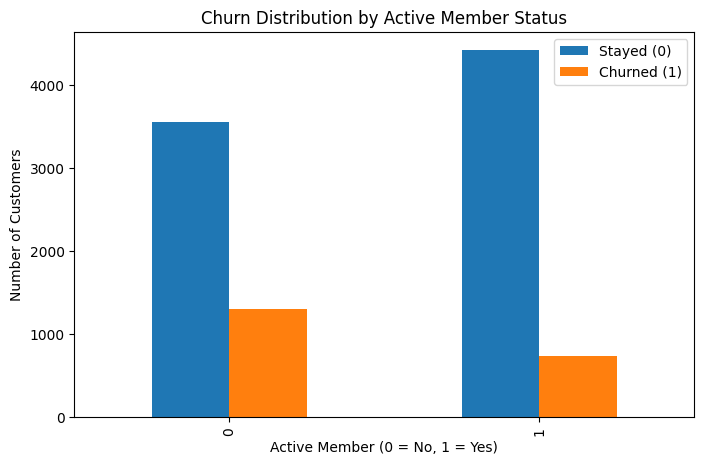

In [29]:
# Calculate churn distribution by active member status
# This helps us understand whether active customers are less likely to churn

active_member_churn = pd.crosstab(
    df["active_member"],
    df["churn"]
)

# Display the churn distribution
print("Churn distribution by active member status:")
print(active_member_churn)

# Plot churn distribution by active member status
active_member_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Active Member Status")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

Churn distribution by credit card ownership:
churn           0     1
credit_card            
0            2332   613
1            5631  1424


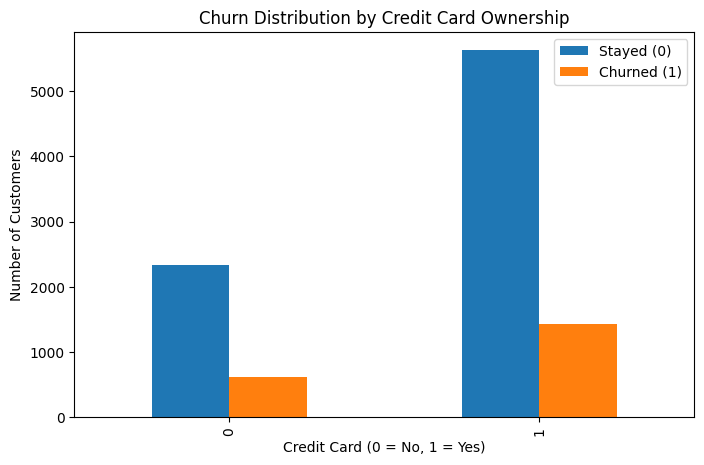

In [30]:
# Calculate churn distribution by credit card ownership
# This helps us understand whether having a credit card is related to churn

credit_card_churn = pd.crosstab(
    df["credit_card"],
    df["churn"]
)

# Display the churn distribution
print("Churn distribution by credit card ownership:")
print(credit_card_churn)

# Plot churn distribution by credit card ownership
credit_card_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

# Add chart title and axis labels
plt.title("Churn Distribution by Credit Card Ownership")
plt.xlabel("Credit Card (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

# Display the legend
plt.legend(["Stayed (0)", "Churned (1)"])

# Display the chart
plt.show()

Average estimated salary by churn status:
churn
0     99738.391772
1    101465.677531
Name: estimated_salary, dtype: float64


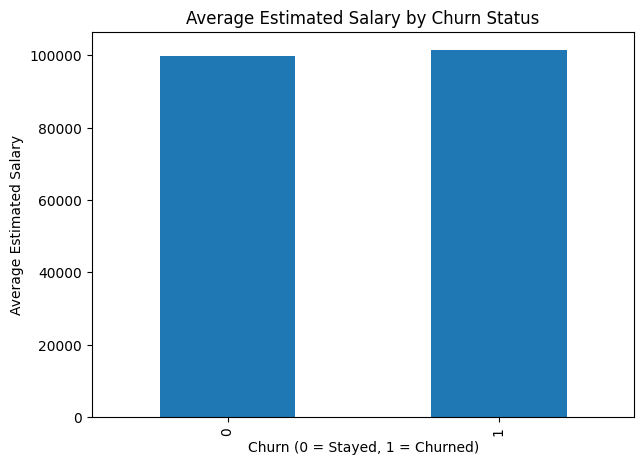

In [31]:
# Compare the average estimated salary between churned and non-churned customers
# This helps us check whether salary level shows a noticeable difference in churn behavior

salary_churn = df.groupby("churn")["estimated_salary"].mean()

# Display the average salary for each churn category
print("Average estimated salary by churn status:")
print(salary_churn)

# Plot the average salary for each churn category
salary_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

# Add chart title and axis labels
plt.title("Average Estimated Salary by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Average Estimated Salary")

# Display the chart
plt.show()

Correlation Matrix:
                  credit_score       age    tenure   balance  products_number  \
credit_score          1.000000 -0.003965  0.000842  0.006268         0.012238   
age                  -0.003965  1.000000 -0.009997  0.028308        -0.030680   
tenure                0.000842 -0.009997  1.000000 -0.012254         0.013444   
balance               0.006268  0.028308 -0.012254  1.000000        -0.304180   
products_number       0.012238 -0.030680  0.013444 -0.304180         1.000000   
credit_card          -0.005458 -0.011721  0.022583 -0.014858         0.003183   
active_member         0.025651  0.085472 -0.028362 -0.010084         0.009612   
estimated_salary     -0.001384 -0.007201  0.007784  0.012797         0.014204   
churn                -0.027094  0.285323 -0.014001  0.118533        -0.047820   

                  credit_card  active_member  estimated_salary     churn  
credit_score        -0.005458       0.025651         -0.001384 -0.027094  
age                

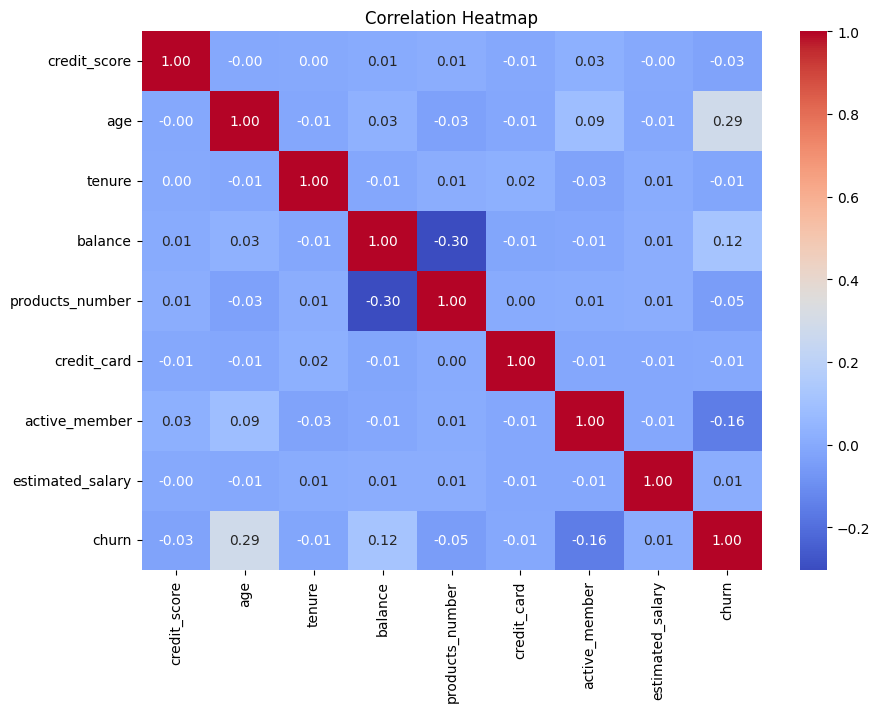

In [32]:
# Select numerical columns for correlation analysis
# Correlation helps us understand relationships between numerical features

numerical_columns = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary",
    "churn"
]

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Create a heatmap to visualize correlations
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Add chart title
plt.title("Correlation Heatmap")

# Display the chart
plt.show()

In [33]:
# Create a copy of the dataset for Machine Learning preprocessing
# Keeping the original dataframe unchanged allows us to refer back to the EDA results

ml_df = df.copy()

# Remove customer ID because it is only an identifier and does not provide predictive information
# Remove age_group and credit_score_group because these were created only for EDA analysis

ml_df = ml_df.drop(
    columns=["customer_id", "age_group", "credit_score_group"]
)

# Display the remaining columns
print("Columns used for Machine Learning:")
print(ml_df.columns.tolist())

# Display the shape of the ML dataset
print("\nML dataset shape:", ml_df.shape)

Columns used for Machine Learning:
['credit_score', 'country', 'gender', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn']

ML dataset shape: (10000, 11)


In [34]:
# Separate the target variable from the input features
# The target variable is what our Machine Learning model will predict

X = ml_df.drop(columns=["churn"])

# Store the churn column as the target variable
y = ml_df["churn"]

# Display the shape of features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display the target distribution
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (10000, 10)
Target shape: (10000,)

Target distribution:
churn
0    7963
1    2037
Name: count, dtype: int64


In [35]:
# Convert categorical columns into numerical features
# Machine Learning models work with numerical values rather than text categories

X_encoded = pd.get_dummies(
    X,
    columns=["country", "gender"],
    drop_first=True,
    dtype=int
)

# Display the first few rows after encoding
print("Encoded feature data:")
print(X_encoded.head())

# Display the updated feature columns
print("\nEncoded feature columns:")
print(X_encoded.columns.tolist())

# Display the shape after encoding
print("\nEncoded features shape:", X_encoded.shape)

Encoded feature data:
   credit_score  age  tenure    balance  products_number  credit_card  \
0           619   42       2       0.00                1            1   
1           608   41       1   83807.86                1            0   
2           502   42       8  159660.80                3            1   
3           699   39       1       0.00                2            0   
4           850   43       2  125510.82                1            1   

   active_member  estimated_salary  country_Germany  country_Spain  \
0              1         101348.88                0              0   
1              1         112542.58                0              1   
2              0         113931.57                0              0   
3              0          93826.63                0              0   
4              1          79084.10                0              1   

   gender_Male  
0            0  
1            0  
2            0  
3            0  
4            0  

Encoded feature

In [36]:
# Split the dataset into training and testing sets
# The model will learn from the training data and be evaluated on unseen test data

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the training and testing datasets
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (8000, 11)
Testing features shape: (2000, 11)
Training target shape: (8000,)
Testing target shape: (2000,)


In [37]:
# Create a StandardScaler to normalize numerical feature values
# Standardization puts features on a comparable scale

scaler = StandardScaler()

# Fit the scaler only on training data and transform the training features
# Fitting only on training data prevents data leakage

X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to transform the test features
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the scaled datasets
print("Scaled training features shape:", X_train_scaled.shape)
print("Scaled testing features shape:", X_test_scaled.shape)

# Confirm that feature scaling was completed
print("\nFeature scaling completed successfully!")

Scaled training features shape: (8000, 11)
Scaled testing features shape: (2000, 11)

Feature scaling completed successfully!


In [38]:
# Create a Logistic Regression model
# Logistic Regression is a classification algorithm used to predict binary outcomes

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model using the scaled training data
logistic_model.fit(X_train_scaled, y_train)

# Generate predictions on the unseen test data
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Calculate the model accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

# Display the accuracy
print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.808


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



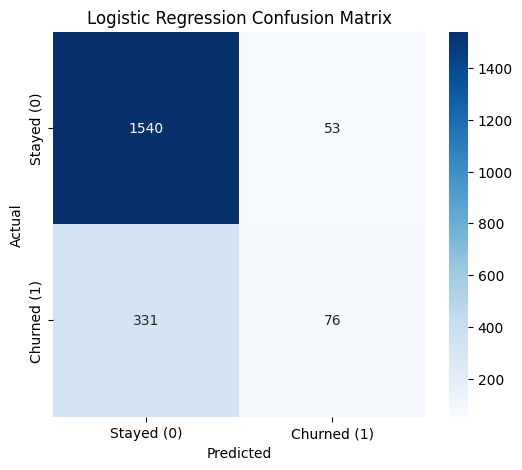

In [39]:
# Generate a detailed classification report
# This shows precision, recall, and F1-score for both churn classes

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))

# Create a confusion matrix
# This shows correct and incorrect predictions made by the model

logistic_cm = confusion_matrix(y_test, y_pred_logistic)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed (0)", "Churned (1)"],
    yticklabels=["Stayed (0)", "Churned (1)"]
)

# Add chart title and axis labels
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the chart
plt.show()

In [40]:
# Create a Random Forest classification model
# Random Forest combines multiple decision trees to make predictions

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the Random Forest model using the training data
# Random Forest does not require scaled features, so we use the original encoded features

random_forest_model.fit(X_train, y_train)

# Generate predictions on the unseen test data
y_pred_rf = random_forest_model.predict(X_test)

# Calculate the model accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Display the Random Forest accuracy
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.863


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



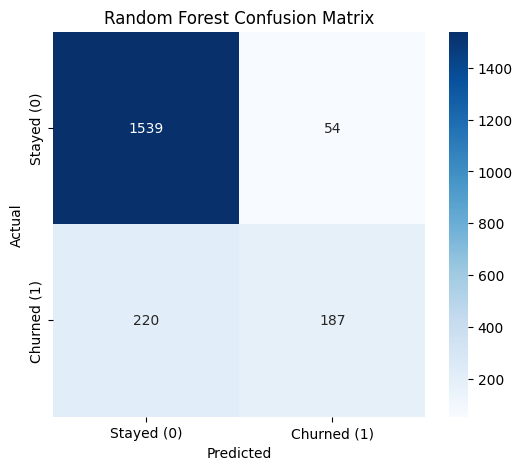

In [41]:
# Generate a detailed classification report for the Random Forest model
# This shows precision, recall, and F1-score for each churn class

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Create a confusion matrix for the Random Forest model
rf_cm = confusion_matrix(y_test, y_pred_rf)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed (0)", "Churned (1)"],
    yticklabels=["Stayed (0)", "Churned (1)"]
)

# Add chart title and axis labels
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the chart
plt.show()

In [42]:
# Check whether XGBoost is installed
# XGBoost will be used as another classification model for churn prediction

import xgboost as xgb

# Display the installed XGBoost version
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [43]:
# Create an XGBoost classification model
# XGBoost builds an ensemble of decision trees to improve prediction performance

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

# Train the XGBoost model using the training data
xgb_model.fit(X_train, y_train)

# Generate predictions on the unseen test data
y_pred_xgb = xgb_model.predict(X_test)

# Calculate the model accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

# Display the XGBoost accuracy
print("XGBoost Accuracy:", xgb_accuracy) 

XGBoost Accuracy: 0.867


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.47      0.59       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



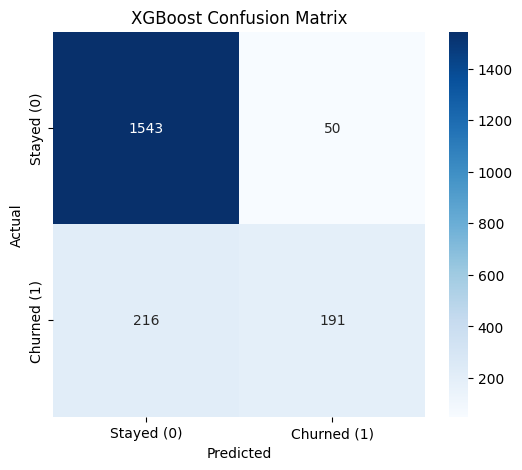

In [44]:
# Generate a detailed classification report for the XGBoost model
# This helps us evaluate how well the model identifies churned customers

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Create a confusion matrix for the XGBoost model
xgb_cm = confusion_matrix(y_test, y_pred_xgb)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed (0)", "Churned (1)"],
    yticklabels=["Stayed (0)", "Churned (1)"]
)

# Add chart title and axis labels
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the chart
plt.show()

In [45]:
# Compare the accuracy of all trained Machine Learning models
# This gives us a simple overview of the model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

# Convert accuracy values into percentages
model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
).round(2)

# Display the model comparison
print("Model Performance Comparison:")
print(model_comparison)

Model Performance Comparison:
                 Model  Accuracy  Accuracy (%)
0  Logistic Regression     0.808          80.8
1        Random Forest     0.863          86.3
2              XGBoost     0.867          86.7


In [46]:
# Calculate ROC-AUC scores for all three Machine Learning models
# ROC-AUC measures how well a model separates churned and non-churned customers

# Generate churn probabilities for each model
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC for each model
logistic_auc = roc_auc_score(y_test, logistic_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

# Display the ROC-AUC scores
print("ROC-AUC Scores:")
print("Logistic Regression:", round(logistic_auc, 3))
print("Random Forest:", round(rf_auc, 3))
print("XGBoost:", round(xgb_auc, 3))

ROC-AUC Scores:
Logistic Regression: 0.775
Random Forest: 0.852
XGBoost: 0.867


XGBoost Feature Importance:
             Feature  Importance
4    products_number    0.263386
6      active_member    0.213208
1                age    0.173931
8    country_Germany    0.119387
3            balance    0.057434
10       gender_Male    0.049077
9      country_Spain    0.030943
0       credit_score    0.027574
7   estimated_salary    0.024905
2             tenure    0.023882
5        credit_card    0.016275


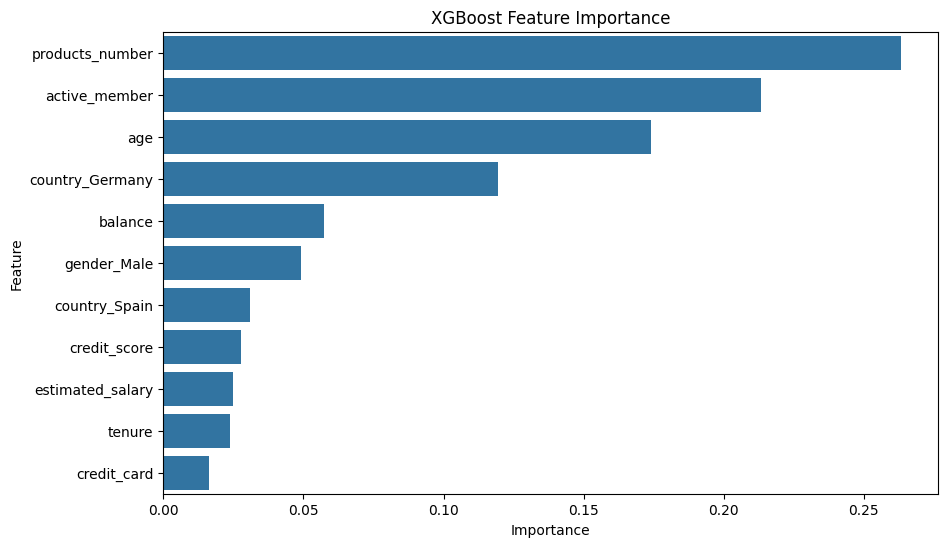

In [47]:
# Extract feature importance from the trained XGBoost model
# Feature importance shows which features contributed most to the model's predictions

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance values
print("XGBoost Feature Importance:")
print(feature_importance)

# Plot the feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

# Add chart title and axis labels
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Display the chart
plt.show()

In [48]:
# Create a sample customer for churn prediction
# The values represent a hypothetical bank customer

new_customer = pd.DataFrame({
    "credit_score": [650],
    "country": ["Germany"],
    "gender": ["Female"],
    "age": [45],
    "tenure": [5],
    "balance": [85000],
    "products_number": [2],
    "credit_card": [1],
    "active_member": [0],
    "estimated_salary": [75000]
})

# Apply the same one-hot encoding used during model training
new_customer_encoded = pd.get_dummies(
    new_customer,
    columns=["country", "gender"],
    drop_first=True,
    dtype=int
)

# Make sure the new customer has exactly the same feature columns as the training data
new_customer_encoded = new_customer_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Predict the churn class
new_customer_prediction = xgb_model.predict(new_customer_encoded)[0]

# Predict the probability of churn
new_customer_probability = xgb_model.predict_proba(
    new_customer_encoded
)[0, 1]

# Display the prediction result
print("Predicted Churn:", new_customer_prediction)
print("Churn Probability:", round(new_customer_probability * 100, 2), "%")

Predicted Churn: 0
Churn Probability: 25.37 %


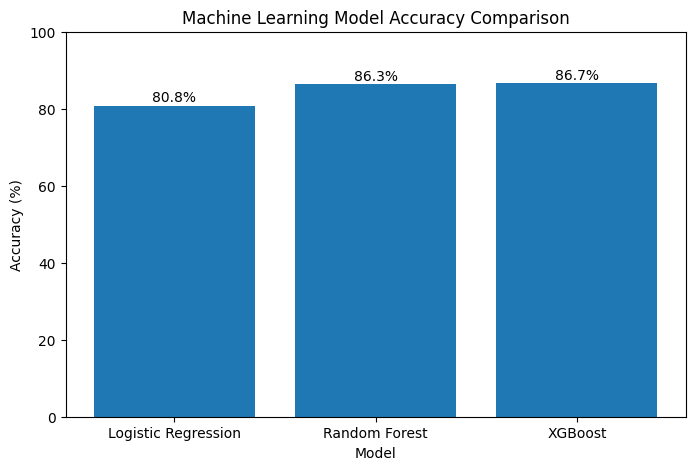

In [49]:
# Create a comparison chart for all trained Machine Learning models
# This makes it easier to compare model accuracy visually

plt.figure(figsize=(8, 5))

# Plot model accuracy values
plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy (%)"]
)

# Add chart title and axis labels
plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

# Set the y-axis range for better comparison
plt.ylim(0, 100)

# Display accuracy values above each bar
for i, accuracy in enumerate(model_comparison["Accuracy (%)"]):
    plt.text(
        i,
        accuracy + 1,
        f"{accuracy}%",
        ha="center"
    )

# Display the chart
plt.show()

## 📌 Final Conclusion

This project developed a Machine Learning pipeline to predict customer churn using banking customer data.

Three classification models were trained and evaluated:

- Logistic Regression achieved 80.8% accuracy and 0.775 ROC-AUC.
- Random Forest achieved 86.3% accuracy and 0.852 ROC-AUC.
- XGBoost achieved 86.7% accuracy and 0.867 ROC-AUC.

The XGBoost model showed the highest accuracy and ROC-AUC among the three evaluated models.

Feature importance analysis showed that products number, active member status, age, and country were among the most important features used by the XGBoost model.

The final model was also used to generate a churn prediction and churn probability for a sample customer.

Overall, this project demonstrates an end-to-end Machine Learning workflow including data cleaning, exploratory data analysis, feature engineering, preprocessing, model training, evaluation, feature importance analysis, and customer churn prediction.